In [1]:
import py7zr

archive = py7zr.SevenZipFile('train.7z', mode='r')
archive.extractall()
archive.close()

Importing the Dependencies

In [2]:
import os
import numpy as np
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.image as  mpimg
from sklearn.model_selection import train_test_split

In [3]:
filenames = os.listdir('train/')

In [4]:
type(filenames)

list

In [5]:
len(filenames)

50000

Labels Processing

In [6]:
labels_df = pd.read_csv('trainLabels.csv')

In [7]:
labels_df.shape

(50000, 2)

In [8]:
labels_df.head()

,id,label
0,1,frog
1,2,truck
2,3,truck
3,4,deer
4,5,automobile


In [9]:
labels_df.label.value_counts()

label
frog          5000
truck         5000
deer          5000
automobile    5000
bird          5000
horse         5000
ship          5000
cat           5000
dog           5000
airplane      5000
Name: count, dtype: int64

In [10]:
labels_dict = {'airplane':0,'automobile':1,'bird':2,'cat':3,'deer':4,'dog':5,'frog':6,'horse':7,'ship':8,'truck':9}

labels = [labels_dict[i] for i in labels_df['label']]

In [11]:
labels[0:5]

[6, 9, 9, 4, 1]

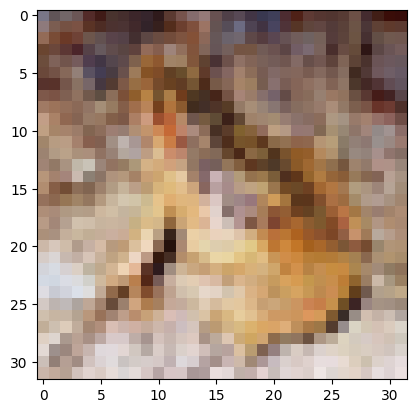

In [12]:
# displaying sample image
demo = mpimg.imread('train/7796.png')
plt.imshow(demo)

In [13]:
id_list = list(labels_df['id'])

**Image Processing**

In [14]:
# converting images to numpy array

train_data_folder = 'train/'

data = []

for id in id_list:
    image = Image.open(train_data_folder+str(id)+'.png')
    image = np.array(image)
    data.append(image)


In [15]:
type(data)

list

In [16]:
len(data)

50000

In [17]:
type(data[0])

numpy.ndarray

In [18]:
data[0].shape

(32, 32, 3)

In [19]:
data[0]

array([[[ 59,  62,  63],
        [ 43,  46,  45],
        [ 50,  48,  43],
        ...,
        [158, 132, 108],
        [152, 125, 102],
        [148, 124, 103]],

       [[ 16,  20,  20],
        [  0,   0,   0],
        [ 18,   8,   0],
        ...,
        [123,  88,  55],
        [119,  83,  50],
        [122,  87,  57]],

       [[ 25,  24,  21],
        [ 16,   7,   0],
        [ 49,  27,   8],
        ...,
        [118,  84,  50],
        [120,  84,  50],
        [109,  73,  42]],

       ...,

       [[208, 170,  96],
        [201, 153,  34],
        [198, 161,  26],
        ...,
        [160, 133,  70],
        [ 56,  31,   7],
        [ 53,  34,  20]],

       [[180, 139,  96],
        [173, 123,  42],
        [186, 144,  30],
        ...,
        [184, 148,  94],
        [ 97,  62,  34],
        [ 83,  53,  34]],

       [[177, 144, 116],
        [168, 129,  94],
        [179, 142,  87],
        ...,
        [216, 184, 140],
        [151, 118,  84],
        [123,  92,  72]]

In [20]:
# convert image list and label list to numpy arrays
X = np.array(data)
Y = np.array(labels)

In [21]:
print(X.shape)

(50000, 32, 32, 3)


**Train Test Split**

In [22]:
X_train, X_test, Y_train, Y_test = train_test_split(X,Y,test_size=0.2, random_state=2)

In [23]:
print(X.shape, X_train.shape, X_test.shape)

(50000, 32, 32, 3) (40000, 32, 32, 3) (10000, 32, 32, 3)


In [24]:
# scaling the data

X_train_scaled = X_train/255
X_test_scaled = X_test/255

In [25]:
X_train_scaled[0]

array([[[0.81960784, 0.82352941, 0.79607843],
        [0.83529412, 0.83921569, 0.81960784],
        [0.85490196, 0.85882353, 0.84313725],
        ...,
        [0.49803922, 0.29019608, 0.15294118],
        [0.47843137, 0.26666667, 0.1372549 ],
        [0.45490196, 0.24705882, 0.1254902 ]],

       [[0.82352941, 0.82352941, 0.79215686],
        [0.83529412, 0.83921569, 0.81176471],
        [0.85490196, 0.8627451 , 0.83921569],
        ...,
        [0.48627451, 0.2745098 , 0.1372549 ],
        [0.4745098 , 0.2627451 , 0.12941176],
        [0.48235294, 0.27058824, 0.14117647]],

       [[0.80784314, 0.80392157, 0.76470588],
        [0.81960784, 0.81960784, 0.79215686],
        [0.83529412, 0.84313725, 0.81960784],
        ...,
        [0.48627451, 0.2745098 , 0.14509804],
        [0.51372549, 0.30196078, 0.16470588],
        [0.51372549, 0.30588235, 0.16078431]],

       ...,

       [[0.49803922, 0.42352941, 0.38039216],
        [0.54117647, 0.47843137, 0.43137255],
        [0.55294118, 0

Building the Neural Network

In [26]:
import tensorflow as tf
import tf_keras as keras

2025-09-24 06:25:09.873453: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-09-24 06:25:09.910238: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-09-24 06:25:11.069537: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


In [27]:
num_of_classes = 10

#setting up the layers of NN

model = keras.Sequential([
    keras.layers.Flatten(input_shape=(32,32,3)),
    keras.layers.Dense(64, activation='relu'),
    keras.layers.Dense(128, activation='relu'),
    keras.layers.Dense(64, activation='relu'),
    keras.layers.Dense(num_of_classes, activation='softmax') # generally softmax for multiclass / sigmoid for binary classification
])

I0000 00:00:1758674411.696818   12462 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 4102 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4050 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.9


In [28]:
# compiling the NN
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['acc'])

In [29]:
# training the NN
model.fit(X_train_scaled, Y_train, validation_split=0.1, epochs=20)

Epoch 1/20


2025-09-24 06:25:13.008968: I external/local_xla/xla/service/service.cc:163] XLA service 0x7802a57f9130 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2025-09-24 06:25:13.008984: I external/local_xla/xla/service/service.cc:171]   StreamExecutor device (0): NVIDIA GeForce RTX 4050 Laptop GPU, Compute Capability 8.9
2025-09-24 06:25:13.013369: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2025-09-24 06:25:13.028841: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:473] Loaded cuDNN version 91300
I0000 00:00:1758674413.069926   12558 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


1125/1125 [==============================] - 3s 2ms/step - loss: 1.9166 - acc: 0.2990 - val_loss: 1.7677 - val_acc: 0.3530
Epoch 2/20
1125/1125 [==============================] - 2s 2ms/step - loss: 1.7526 - acc: 0.3688 - val_loss: 1.7001 - val_acc: 0.3740
Epoch 3/20
1125/1125 [==============================] - 2s 2ms/step - loss: 1.6822 - acc: 0.3934 - val_loss: 1.6378 - val_acc: 0.3975
Epoch 4/20
1125/1125 [==============================] - 2s 2ms/step - loss: 1.6370 - acc: 0.4104 - val_loss: 1.6440 - val_acc: 0.3968
Epoch 5/20
1125/1125 [==============================] - 2s 2ms/step - loss: 1.6055 - acc: 0.4197 - val_loss: 1.6007 - val_acc: 0.4103
Epoch 6/20
1125/1125 [==============================] - 2s 2ms/step - loss: 1.5786 - acc: 0.4308 - val_loss: 1.5830 - val_acc: 0.4302
Epoch 7/20
1125/1125 [==============================] - 2s 2ms/step - loss: 1.5622 - acc: 0.4343 - val_loss: 1.5553 - val_acc: 0.4385
Epoch 8/20
1125/1125 [==============================] - 2s 2ms/step - los

**ResNET50V2**

In [30]:
from tf_keras import Sequential, models, layers
from tf_keras.layers import Dense, Dropout, Flatten, BatchNormalization
from tf_keras.models import load_model, Model
from tf_keras.applications.resnet50 import ResNet50
from tf_keras import optimizers

In [31]:
cnn_base = ResNet50(weights='imagenet', include_top=False, input_shape=(256,256,3))
cnn_base.summary()

94765736/94765736 [==============================] - 21s 0us/step
Model: "resnet50"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_1 (InputLayer)        [(None, 256, 256, 3)]        0         []                            
                                                                                                  
 conv1_pad (ZeroPadding2D)   (None, 262, 262, 3)          0         ['input_1[0][0]']             
                                                                                                  
 conv1_conv (Conv2D)         (None, 128, 128, 64)         9472      ['conv1_pad[0][0]']           
                                                                                                  
 conv1_bn (BatchNormalizati  (None, 128, 128, 64)         256       ['conv1_conv[0][0]']          
 on)                     

In [33]:
model = models.Sequential()
model.add(layers.UpSampling2D((2,2))) # image shape (32,32) is upsampled by (2,2) ie (32*2,32*2)
model.add(layers.UpSampling2D((2,2)))
model.add(layers.UpSampling2D((2,2)))
model.add(cnn_base)
model.add(Flatten())
model.add(BatchNormalization())
model.add(Dense(128, activation='relu'))
model.add(Dropout(0.5))
model.add(BatchNormalization())
model.add(Dense(64, activation='relu'))
model.add(Dropout(0.5))
model.add(BatchNormalization())
model.add(Dense(num_of_classes, activation='softmax'))

In [34]:
model.compile(optimizer=optimizers.RMSprop(learning_rate=2e-5), loss='sparse_categorical_crossentropy', metrics=['acc'])

In [37]:
history = model.fit(X_train_scaled, Y_train, validation_split=0.1, epochs=10, batch_size=16)

Epoch 1/10
2250/2250 [==============================] - 437s 188ms/step - loss: 1.8885 - acc: 0.3653 - val_loss: 0.8508 - val_acc: 0.7628
Epoch 2/10
2250/2250 [==============================] - 424s 188ms/step - loss: 1.2946 - acc: 0.5831 - val_loss: 0.5686 - val_acc: 0.8515
Epoch 3/10
2250/2250 [==============================] - 424s 188ms/step - loss: 1.0212 - acc: 0.6977 - val_loss: 0.4071 - val_acc: 0.8950
Epoch 4/10
2250/2250 [==============================] - 424s 188ms/step - loss: 0.8370 - acc: 0.7671 - val_loss: 0.3346 - val_acc: 0.9120
Epoch 5/10
2250/2250 [==============================] - 424s 188ms/step - loss: 0.7056 - acc: 0.8120 - val_loss: 0.2933 - val_acc: 0.9185
Epoch 6/10
2250/2250 [==============================] - 424s 189ms/step - loss: 0.6030 - acc: 0.8454 - val_loss: 0.2672 - val_acc: 0.9283
Epoch 7/10
2250/2250 [==============================] - 424s 188ms/step - loss: 0.5161 - acc: 0.8704 - val_loss: 0.2591 - val_acc: 0.9285
Epoch 8/10
2250/2250 [============

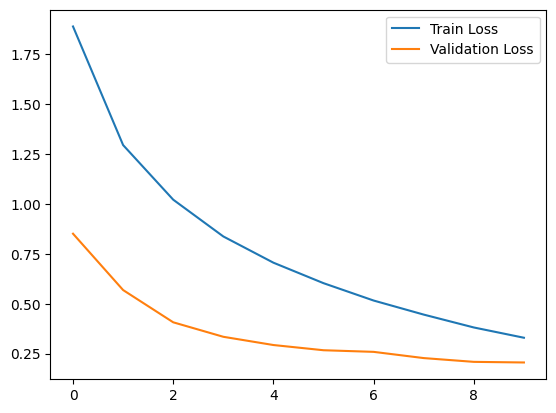

In [39]:
# plot the loss value
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend()
plt.show()

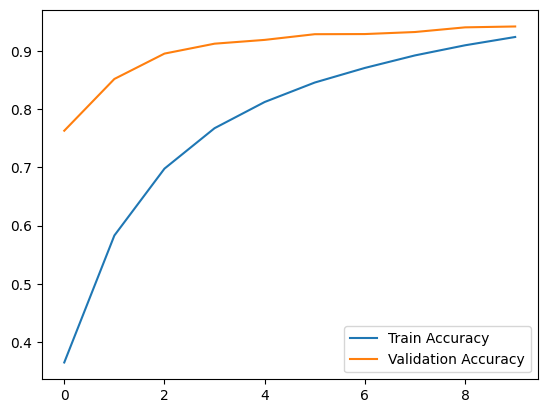

In [40]:
# plot the Accuracy value
plt.plot(history.history['acc'], label='Train Accuracy')
plt.plot(history.history['val_acc'], label='Validation Accuracy')
plt.legend()
plt.show()

In [41]:
loss, accuracy = model.evaluate(X_test_scaled, Y_test)
print('Test Accuracy = ', accuracy)
print('Test Loss = ', loss)

313/313 [==============================] - 32s 97ms/step - loss: 0.2197 - acc: 0.9353
Test Accuracy =  0.9352999925613403
Test Loss =  0.21969819068908691
